In [1]:
import sys
sys.path.insert(1, '../../../Utils/')
from classes_unet import *
from sklearn.model_selection import KFold

number_of_the_seed = 2020

random.seed(number_of_the_seed)
set_seed(number_of_the_seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

C:\Users\iisaragon\anaconda3\envs\torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\iisaragon\anaconda3\envs\torch\lib\site-packages\torch\nn\_reduction.py:42: UserWarning: size_average and reduce args will be deprecated, please use reduction='mean' instead.
  warnings.warn(warning.format(ret))


In [2]:
path=Path('../../../../Datasets/Processed/dataset/')
path_train=path/'train_def'
path_model=Path('../models/kfold_deeplab')

In [3]:
transforms=Compose([HorizontalFlip(p=0.5),Rotate(p=0.40,limit=10)],p=1)
transformPipeline=SegmentationAlbumentationsTransform(transforms)

In [4]:
img = PILImage.create(path_train/'Blast_PCRM_1201754 D5.BMP')
img = transform_image(img)

In [5]:
codes = np.array(['Background','ZP', 'TE', 'ICM'])

In [6]:
bs = 2
callbacks = [EarlyStoppingCallback(patience=3),SaveModelCallback(fname='model'),ReduceLROnPlateau(patience=3)]
opt = ranger

In [7]:
get_y_fn = lambda x: Path(str(x).replace("train_def","GT_Mask"))

In [8]:
def datablock(indx_valid):
    return DataBlock(blocks=(ImageBlock, MaskBlock(codes)),
              get_items=get_files,
              get_y=get_y_fn,
              splitter=IndexSplitter(indx_valid),
              item_tfms=[Resize((480,480)), TargetMaskConvertTransform(), transformPipeline],
              batch_tfms=Normalize.from_stats(*imagenet_stats))

In [9]:
wd = [1e-1, 5e-2, 1e-2, 5e-3, 1e-3, 5e-4, 1e-4, 5e-5, 1e-5, 1e-6]

In [12]:
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

In [ ]:
k=1
for indx_train, indx_valid in kfold.split(get_files(path_train)):
    trainDB = datablock(indx_valid)
    trainDLS = trainDB.dataloaders(path_train,bs=bs)
    learn = get_segmentation_learner(dls=trainDLS, number_classes=4, segmentation_type="Semantic Segmentation",
                                 architecture_name="hrnet", backbone_name="hrnet_w30", 
                                 metrics=[background,zp,te,icm,msa],wd=wd[k],
                                 pretrained=True,normalize=True).to_fp16()
    lr_steep=learn.lr_find()
    learn.fit_one_cycle(20,lr_steep)
    learn.fit_one_cycle(20,lr_steep)
    learn.unfreeze()
    lr_steep=learn.lr_find()
    learn.fit_one_cycle(5,lr_steep)
    aux=learn.model
    aux=aux.cpu()
    img=img.cpu()
    traced_cell=torch.jit.trace(aux, (img))
    traced_cell.save(str(path_model)+f"{k}.pth")
    k+=1

epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.359228,1.414010,0.580921,0.884087,0.848740,0.812939,0.815258,01:10
1,0.297904,2.152024,0.002961,0.742292,0.720820,0.687531,0.629510,01:12
2,0.302544,1.383942,0.118519,0.666091,0.666726,0.652044,0.595920,01:11
3,0.291910,1.334825,0.301436,0.585704,0.664811,0.650171,0.594085,01:10
4,0.298501,11.174728,0.000007,0.621630,0.603683,0.576667,0.527296,01:10
5,0.269415,0.657767,0.874193,0.771579,0.780204,0.783829,0.790327,01:11
6,0.262939,0.489311,0.786897,0.813821,0.827386,0.855836,0.827359,01:12
7,0.247876,0.761283,0.544210,0.829592,0.847095,0.859940,0.809277,01:08
8,0.230317,0.445379,0.752777,0.811648,0.844529,0.801974,0.810852,01:11
9,0.212491,0.239386,0.829000,0.912411,0.920868,0.906535,0.902702,01:13


epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.138928,0.177878,0.911042,0.928888,0.937869,0.924651,0.927983,01:08
1,0.146392,0.198534,0.879674,0.934909,0.928622,0.920059,0.921653,01:05
2,0.167806,0.391020,0.876809,0.869677,0.882334,0.860046,0.871095,01:06
3,0.193590,0.223485,0.863569,0.919210,0.914488,0.918877,0.910974,01:06
4,0.199077,0.291652,0.855685,0.894809,0.909904,0.887201,0.891995,01:05
5,0.202138,0.394897,0.862944,0.872064,0.879955,0.861515,0.869690,01:06
6,0.199150,0.205857,0.860466,0.922705,0.927705,0.919712,0.915723,01:07
7,0.186838,0.218181,0.898049,0.912736,0.916626,0.914902,0.912786,01:05
8,0.186437,0.238833,0.873133,0.900248,0.913464,0.915033,0.905371,01:09
9,0.171848,0.216635,0.844394,0.911240,0.938122,0.912325,0.911081,01:09


epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.110289,0.173593,0.899576,0.937643,0.943129,0.933564,0.933290,01:11
1,0.106646,0.173364,0.903221,0.937527,0.942865,0.933639,0.933666,01:11
2,0.105665,0.174015,0.901020,0.938331,0.942899,0.933648,0.933627,01:10
3,0.107055,0.174223,0.902404,0.938275,0.942685,0.933713,0.933738,01:21
4,0.104386,0.174498,0.902351,0.938296,0.942484,0.933602,0.933646,01:19


epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.963491,1.127472,0.822660,0.727495,0.698989,0.700983,0.723644,01:18
1,0.505613,0.632878,0.853857,0.885706,0.876798,0.871242,0.875248,01:07
2,0.307522,0.388064,0.867665,0.901946,0.904846,0.893131,0.896541,01:09
3,0.247580,0.297708,0.860390,0.918007,0.911958,0.911526,0.907594,01:12
4,0.225512,0.330530,0.786182,0.905175,0.933653,0.893328,0.895435,01:10
5,0.192205,0.252965,0.846888,0.919063,0.910014,0.913699,0.906443,01:09
6,0.179698,0.248182,0.822799,0.923882,0.923426,0.920836,0.911064,01:11
7,0.162344,0.243859,0.887506,0.913998,0.915326,0.921492,0.913906,01:12
8,0.147091,0.260564,0.874736,0.911448,0.914601,0.923293,0.911867,01:07
9,0.136925,0.246510,0.870403,0.925193,0.923943,0.915934,0.915398,01:10


epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.074982,0.256723,0.875974,0.928656,0.935900,0.927968,0.924302,00:58
1,0.077737,0.263662,0.868388,0.928096,0.937894,0.928535,0.924008,00:53
2,0.082783,0.284345,0.859261,0.928026,0.929516,0.924984,0.919599,01:02
3,0.092354,0.393251,0.762522,0.900386,0.926146,0.923596,0.898533,00:59
4,0.099685,0.263091,0.868061,0.921078,0.932837,0.923767,0.919128,01:03
5,0.102292,0.276846,0.885463,0.919952,0.927835,0.919531,0.918253,00:58
6,0.108660,0.257152,0.887008,0.919939,0.923709,0.918007,0.916779,00:58
7,0.100814,0.252558,0.876060,0.922052,0.931773,0.927781,0.921346,00:57
8,0.091717,0.254373,0.855175,0.929123,0.938289,0.924967,0.921797,01:00
9,0.081354,0.261706,0.884369,0.923355,0.938214,0.927120,0.924248,00:59


...

epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.051607,0.238184,0.897881,0.935495,0.938011,0.928849,0.928514,01:00
1,0.052238,0.251810,0.891995,0.931403,0.937812,0.926164,0.925690,00:58
2,0.051451,0.244194,0.895176,0.933251,0.939617,0.928704,0.927928,00:58
3,0.049814,0.244582,0.894973,0.934137,0.939369,0.928998,0.928201,00:57
4,0.049373,0.248580,0.894044,0.934405,0.939169,0.928676,0.927949,01:00


epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.837885,1.045334,0.718319,0.778500,0.689327,0.715805,0.725741,00:58
1,0.422287,0.687164,0.813339,0.864021,0.834654,0.835067,0.839695,00:59
2,0.281898,0.398062,0.769362,0.888503,0.885538,0.876233,0.867070,01:00
3,0.230313,0.360424,0.756876,0.890356,0.879662,0.895469,0.869797,00:57
4,0.210986,0.411849,0.687557,0.882556,0.879760,0.860196,0.847248,00:58
5,0.196133,0.382096,0.829235,0.876014,0.884471,0.860224,0.867174,00:59
6,0.170022,0.333676,0.827490,0.897112,0.907194,0.892460,0.888735,01:00
7,0.153636,0.378094,0.745858,0.885044,0.905748,0.882300,0.870464,00:58
8,0.143751,0.362115,0.794149,0.892717,0.900983,0.897130,0.882426,00:58
9,0.132165,0.354677,0.840218,0.904254,0.896648,0.888089,0.887935,00:59


epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.077236,0.367528,0.850072,0.916238,0.909702,0.906169,0.901880,00:58
1,0.079092,0.367662,0.848038,0.915002,0.912514,0.903334,0.901301,00:57
2,0.086161,0.470110,0.830610,0.897017,0.907955,0.884781,0.886956,01:00
3,0.102907,0.404162,0.844759,0.897521,0.909258,0.887658,0.890567,00:57
4,0.111220,0.362473,0.838376,0.904583,0.908063,0.897047,0.893970,00:57
5,0.102060,0.338833,0.841443,0.914979,0.914864,0.903447,0.901175,00:56
6,0.102359,0.373340,0.863194,0.903303,0.901471,0.891401,0.893633,01:00
7,0.110401,0.501803,0.758389,0.895001,0.894087,0.885004,0.872316,00:56
8,0.097971,0.357427,0.829630,0.908134,0.902393,0.902327,0.893708,00:57
9,0.092118,0.369184,0.817801,0.902825,0.900409,0.898820,0.888996,00:57


epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.054467,0.440696,0.846349,0.913833,0.911318,0.904862,0.900891,00:58
1,0.055889,0.454534,0.843999,0.911463,0.913511,0.904373,0.900384,00:59
2,0.058547,0.442701,0.848530,0.912694,0.913991,0.908666,0.902827,01:00
3,0.052961,0.443325,0.852030,0.913438,0.912369,0.907768,0.902780,00:57
4,0.050301,0.443516,0.851172,0.913431,0.913162,0.908037,0.902971,00:58


epoch,train_loss,valid_loss,background,zp,te,icm,msa,time
0,0.793325,1.010071,0.798180,0.798366,0.735614,0.747462,0.765011,00:59
1,0.406239,0.518816,0.832790,0.894131,0.872428,0.891911,0.879287,00:57
2,0.283265,0.346067,0.781730,0.925356,0.900658,0.882508,0.886907,00:58
3,0.238630,0.281466,0.827578,0.915382,0.890748,0.899881,0.892376,01:00
4,0.214305,0.312372,0.801237,0.887593,0.895003,0.917396,0.887535,00:59
5,0.204451,0.256000,0.831170,0.912684,0.922344,0.913669,0.905387,00:58
6,0.195445,0.235296,0.828658,0.923158,0.918953,0.921264,0.909416,00:58


In [6]:
import sys
sys.path.insert(1, '../Utils/')
from classes_unet import *
from metrics import *

In [7]:
path_test=path/'test_def'
files=[path_test/f for f in os.listdir(path_test)]
gtruth_zp=[get_mask(f,'ZP',path) for f in files]
gtruth_te=[get_mask(f,'TE',path) for f in files]
gtruth_icm=[get_mask(f,'ICM',path) for f in files]

In [12]:
path_model=Path('../models/')

In [14]:
ZP={'accuracy':[],'precision':[],'recall':[],'specificity':[],'jaccard':[],'dice':[]}
TE={'accuracy':[],'precision':[],'recall':[],'specificity':[],'jaccard':[],'dice':[]}
ICM={'accuracy':[],'precision':[],'recall':[],'specificity':[],'jaccard':[],'dice':[]}
for k in range(1,10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
    file=f"kfold_deeplab/kfold_deeplab{k}.pth"
    model = torch.jit.load(path_model/file)
    model = model.cpu()
    preds=[prediccion(f,model) for f in files]
    preds_zp=[255*(p==75).astype('uint8') for p in preds]  
    preds_te=[255*(p==255).astype('uint8') for p in preds]
    preds_icm=[255*(p==150).astype('uint8') for p in preds]  
    metrics_zp=summary_metrics(gtruth_zp,preds_zp)
    for keys in ZP:
        ZP[keys].append(metrics_zp[keys])
    metrics_te=summary_metrics(gtruth_te,preds_te)
    for keys in TE:
        TE[keys].append(metrics_te[keys])
    metrics_icm=summary_metrics(gtruth_icm,preds_icm)
    for keys in ICM:
        ICM[keys].append(metrics_icm[keys])

In [15]:
def r(n):
    return(round(n,4))

In [16]:
for k in ZP:
    print(k + ': ' +str(r(np.mean(ZP[k]))),str(r(np.std(ZP[k]))))

accuracy: 0.9669 0.0006
precision: 0.9274 0.005
recall: 0.8332 0.0079
specificity: 0.9896 0.0009
jaccard: 0.784 0.005
dice: 0.8734 0.0035


In [17]:
for k in TE:
    print(k + ': ' +str(r(np.mean(TE[k]))),str(r(np.std(TE[k]))))

accuracy: 0.9674 0.0008
precision: 0.8872 0.0061
recall: 0.8058 0.007
specificity: 0.9874 0.0008
jaccard: 0.7311 0.0063
dice: 0.8412 0.0047


In [18]:
for k in ICM:
    print(k + ': ' +str(r(np.mean(ICM[k]))),str(r(np.std(ICM[k]))))

accuracy: 0.9815 0.0016
precision: 0.9061 0.0109
recall: 0.8592 0.0157
specificity: 0.9922 0.001
jaccard: 0.7867 0.0151
dice: 0.869 0.0145


In [19]:
ZP

{'accuracy': [0.9678847912987109,
  0.966759123283238,
  0.9672555567431417,
  0.9657510916598616,
  0.9665614215170607,
  0.9664776164776021,
  0.9669887460240901,
  0.9668956071690734,
  0.9672538845226386],
 'precision': [0.9296912470897029,
  0.9264835668089975,
  0.9174932995470036,
  0.9323925452435484,
  0.9349343868505283,
  0.928070726706907,
  0.9302024253367458,
  0.9235343043108686,
  0.9238469523441019],
 'recall': [0.8444248906167917,
  0.8353981407247911,
  0.8446965310681599,
  0.8193781105547101,
  0.8244193220347192,
  0.8284042550476127,
  0.8315799596142904,
  0.8344646101657702,
  0.8362152874076365],
 'specificity': [0.9893948478853063,
  0.989624484748377,
  0.9876228694111407,
  0.9900287698472608,
  0.990625950722773,
  0.9904715711014007,
  0.9901502423338041,
  0.9888798525898127,
  0.989436033206306],
 'jaccard': [0.7933801148242088,
  0.7854919106886782,
  0.7869879066714218,
  0.773877253865641,
  0.7807817990405509,
  0.7810421430718838,
  0.7856579679746

In [20]:
TE

{'accuracy': [0.9679859321441139,
  0.9688442695199104,
  0.9663282327767178,
  0.9659977685987499,
  0.9678865139839755,
  0.9675382048093303,
  0.9673283377339661,
  0.967570260543346,
  0.9673388820070336],
 'precision': [0.8976118013959967,
  0.8879646942734212,
  0.8772086825593679,
  0.8838781181896146,
  0.8892744612295517,
  0.8926417306679373,
  0.8866487592797162,
  0.8906375168323643,
  0.8786571321416895],
 'recall': [0.7986134214985227,
  0.8164895619176474,
  0.8073272456492,
  0.7936841063154803,
  0.8112339469144608,
  0.7997139499976018,
  0.8042899596264925,
  0.8086701699392356,
  0.8124748487222476],
 'specificity': [0.9886246203302583,
  0.9876945410605724,
  0.9859804115284146,
  0.9873040672709348,
  0.9875049537386658,
  0.9883321237045393,
  0.9872846494136539,
  0.9873698968253293,
  0.9863623944052989],
 'jaccard': [0.7312196507975163,
  0.7424363510583912,
  0.7258321399692284,
  0.7180272493469545,
  0.7354769953431447,
  0.7298995636749273,
  0.73046953794

In [21]:
ICM

{'accuracy': [0.9787796253230825,
  0.9828050497171935,
  0.9789827123615881,
  0.9802725199916131,
  0.9828554017530854,
  0.9816997804319669,
  0.9821479803352687,
  0.9828923620876128,
  0.982940135275818],
 'precision': [0.8888768167777971,
  0.9080407111116343,
  0.8885203768314618,
  0.9073431273968888,
  0.9092499541397073,
  0.9243337471447388,
  0.906440842894644,
  0.9055098091309354,
  0.9169100142752852],
 'recall': [0.8530488351597704,
  0.8761241858695933,
  0.8460521836918004,
  0.8301457994351845,
  0.8748386449399247,
  0.8423173110417389,
  0.8704462150497932,
  0.8719820912446209,
  0.8676078386442972],
 'specificity': [0.9905393971867104,
  0.9921895736316286,
  0.9907379155177276,
  0.9930148693752866,
  0.9919147659076485,
  0.9940058538779546,
  0.9916318657319474,
  0.9927310291974683,
  0.9925944682151882],
 'jaccard': [0.7728996148314815,
  0.8004989402903829,
  0.7650129754076327,
  0.7638442498828524,
  0.7992598504487693,
  0.781490220327943,
  0.7951690671

In [11]:
os.listdir('..\models\kfold_deeplab')

['kfold_deeplab1.pth',
 'kfold_deeplab2.pth',
 'kfold_deeplab3.pth',
 'kfold_deeplab4.pth',
 'kfold_deeplab5.pth',
 'kfold_deeplab6.pth',
 'kfold_deeplab7.pth',
 'kfold_deeplab8.pth',
 'kfold_deeplab9.pth']

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
file=f"kfold_deeplab1.pth"
model = torch.jit.load(path_model/file)
model = model.cpu()
preds=[prediccion(f,model) for f in files]

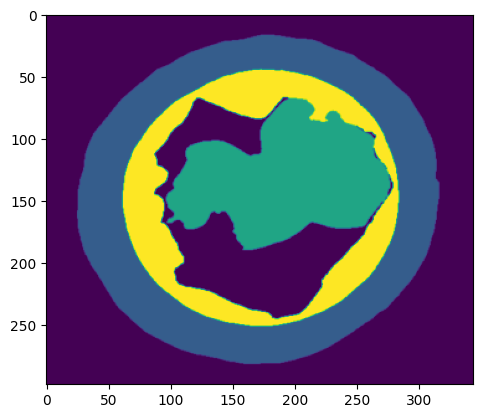

In [24]:
plt.imshow(preds[0])

In [8]:
files[0]

Path('../../../../Datasets/Processed/dataset/test_def/Blast_PCRM_d5.17.BMP')

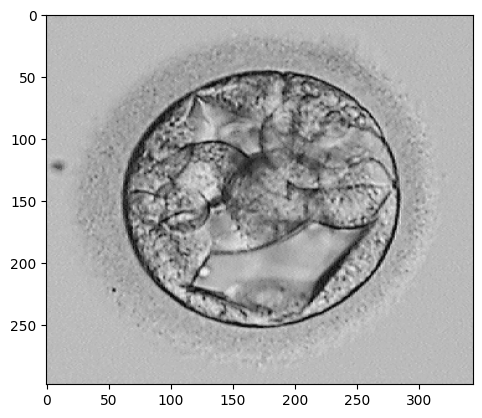

In [9]:
img=cv2.imread(str(files[0]))
plt.imshow(img)

In [12]:
TE=255*(preds[0]==255).astype('uint8')
TE=cv2.dilate(TE, np.ones((3,3)))-TE
img[TE==255]=0
img[:,:,0][TE==255]=255

plt.imshow(img)

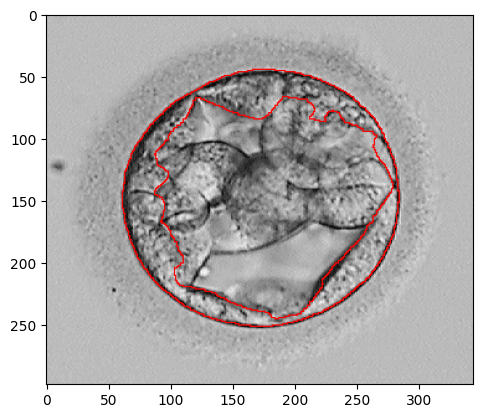

In [13]:
plt.imshow(img)

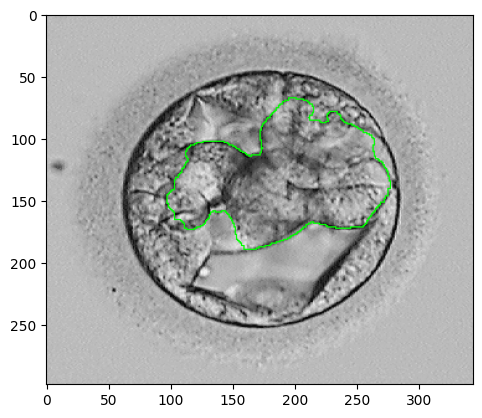

In [14]:
img=cv2.imread(str(files[0]))
plt.imshow(img)

ICM=255*(preds[0]==150).astype('uint8')
ICM=cv2.erode(ICM, np.ones((3,3)))
ICM=cv2.dilate(ICM, np.ones((3,3)))
ICM=cv2.dilate(ICM, np.ones((3,3)))-ICM

img[ICM==255]=0
img[:,:,1][ICM==255]=255
plt.imshow(img)

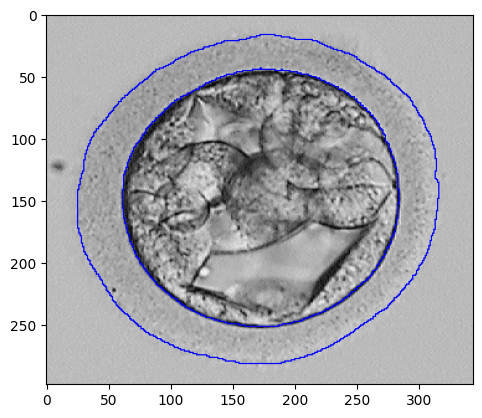

In [15]:
img=cv2.imread(str(files[0]))
plt.imshow(img)

ZP=255*(preds[0]==75).astype('uint8')
ZP=cv2.erode(ZP, np.ones((3,3)))
ZP=cv2.dilate(ZP, np.ones((3,3)))
ZP=cv2.dilate(ZP, np.ones((3,3)))-ZP

img[ZP==255]=0
img[:,:,2][ZP==255]=255
plt.imshow(img)

## IMÁGENES DE CLARA MALO

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
file=f"kfold_deeplab1.pth"
model = torch.jit.load(path_model/file)
model = model.cpu()

In [15]:
path=Path('../../../../Datasets/Processed/Clara/embriones/')
files=[path/f for f in os.listdir(path)]

In [16]:
preds=[prediccion(f,model) for f in files]

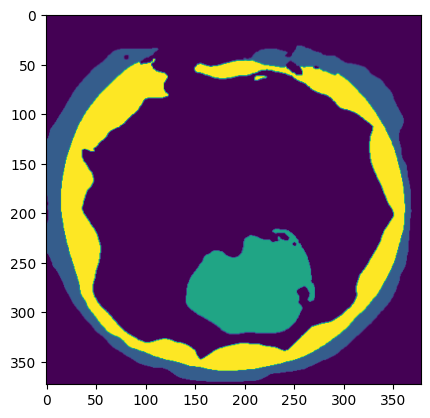

In [17]:
plt.imshow(preds[0])

In [28]:
def pred_te(img,predss):
    TE=255*(predss==255).astype('uint8')
    TE=cv2.dilate(TE, np.ones((3,3)))-TE
    TE=cv2.cvtColor(TE,cv2.COLOR_GRAY2RGB)
    TE[:,:,1]=0
    TE[:,:,0]=0
    return(cv2.addWeighted(img, 0.7, TE, 1, 0.0))

In [23]:
def pred_icm(img,predss):
    ICM=255*(predss==150).astype('uint8')
    ICM=cv2.erode(ICM, np.ones((3,3)))
    ICM=cv2.dilate(ICM, np.ones((3,3)))
    ICM=cv2.dilate(ICM, np.ones((3,3)))-ICM
    ICM=cv2.cvtColor(ICM,cv2.COLOR_GRAY2RGB)
    ICM[:,:,0]=0
    ICM[:,:,2]=0
    return(cv2.addWeighted(img, 0.7, ICM, 1, 0.0))

In [24]:
def pred_zp(img,predss):
    ZP=255*(predss==75).astype('uint8')
    ZP=cv2.erode(ZP, np.ones((3,3)))
    ZP=cv2.dilate(ZP, np.ones((3,3)))
    ZP=cv2.dilate(ZP, np.ones((3,3)))-ZP
    ZP=cv2.cvtColor(ZP,cv2.COLOR_GRAY2RGB)
    return(cv2.addWeighted(img, 0.6, ZP, 1, 0))

In [29]:
i=0
for f in files:
    img=cv2.imread(str(f))
    te=pred_te(img,preds[i])
    icm=pred_icm(img,preds[i])
    zp=pred_zp(img,preds[i])
    cv2.imwrite(f.stem+'_te.png',te)
    cv2.imwrite(f.stem+'_icm.png',icm)
    cv2.imwrite(f.stem+'_zp.png',zp)
    i+=1

In [21]:
files[0].stem

'9695_well01_MRC'

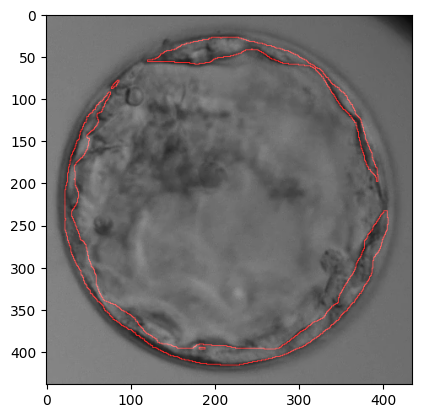

In [115]:
img=cv2.imread(str(files[4]))
TE=255*(preds[4]==255).astype('uint8')
TE=cv2.dilate(TE, np.ones((3,3)))-TE
TE=cv2.cvtColor(TE,cv2.COLOR_GRAY2RGB)
TE[:,:,1]=0
TE[:,:,2]=0
plt.imshow(cv2.addWeighted(img, 0.8, TE, 1, 0.0))

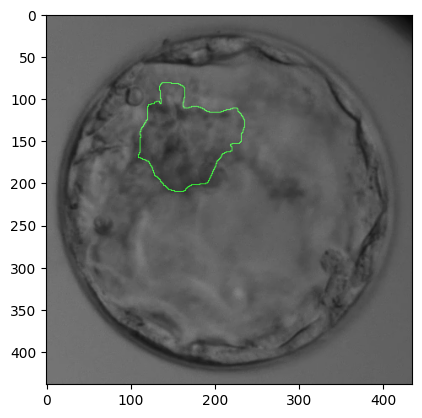

In [116]:
ICM=255*(preds[4]==150).astype('uint8')
ICM=cv2.erode(ICM, np.ones((3,3)))
ICM=cv2.dilate(ICM, np.ones((3,3)))
ICM=cv2.dilate(ICM, np.ones((3,3)))-ICM
ICM=cv2.cvtColor(ICM,cv2.COLOR_GRAY2RGB)
ICM[:,:,0]=0
ICM[:,:,2]=0
plt.imshow(cv2.addWeighted(img, 0.7, ICM, 1, 0.0))

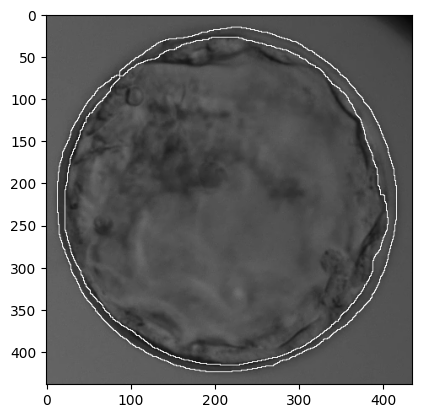

In [117]:
ZP=255*(preds[4]==75).astype('uint8')
ZP=cv2.erode(ZP, np.ones((3,3)))
ZP=cv2.dilate(ZP, np.ones((3,3)))
ZP=cv2.dilate(ZP, np.ones((3,3)))-ZP
ZP=cv2.cvtColor(ZP,cv2.COLOR_GRAY2RGB)
plt.imshow(cv2.addWeighted(img, 0.6, ZP, 1, 0))